# Tutorial 4: Working with Geometries

cendat can fetch geographic boundaries alongside your data for mapping.

**Goal:** Get race data with geometries for US states and create a choropleth map.

## Setup

In [1]:
import os
from cendat import CenDatHelper
from dotenv import load_dotenv

load_dotenv()
cdh = CenDatHelper(key=os.getenv("CENSUS_API_KEY"))
cdh.list_products(years=[2022], patterns=r"acs/acs5\)")
cdh.set_products()

✅ API key loaded successfully.
✅ Product set: 'American Community Survey: 5-Year Estimates: Detailed Tables 5-Year (2022/acs/acs5)' (Vintage: [2022])


## Step 2: Select Data and Geography

In [2]:
cdh.list_groups(patterns=r"^race")

[{'name': 'B25006',
  'description': 'Race of Householder',
  'product': 'American Community Survey: 5-Year Estimates: Detailed Tables 5-Year (2022/acs/acs5)',
  'vintage': [2022],
  'url': 'http://api.census.gov/data/2022/acs/acs5'},
 {'name': 'B02001',
  'description': 'Race',
  'product': 'American Community Survey: 5-Year Estimates: Detailed Tables 5-Year (2022/acs/acs5)',
  'vintage': [2022],
  'url': 'http://api.census.gov/data/2022/acs/acs5'}]

In [3]:
cdh.set_groups(["B02001"])
cdh.describe_groups()

✅ Groups set: B02001

--- Group: B02001 (Race) ---

  Product: American Community Survey: 5-Year Estimates: Detailed Tables 5-Year (2022/acs/acs5) (Vintage: 2022)
      B02001_001E: Total:
        B02001_002E: White alone
        B02001_003E: Black or African American alone
        B02001_004E: American Indian and Alaska Native alone
        B02001_005E: Asian alone
        B02001_006E: Native Hawaiian and Other Pacific Islander alone
        B02001_007E: Some Other Race alone
        B02001_008E: Two or More Races:
          B02001_009E: Two races including Some Other Race
          B02001_010E: Two races excluding Some Other Race, and three or more races


In [4]:
# 040 = States
cdh.set_geos(["040"])

✅ Geographies set: 'state'


## Step 3: Get Data with Geometry

In [5]:
response = cdh.get_data(
    include_names=True,
    include_geometry=True,  # This fetches boundaries from TIGERweb
)

✅ Variables set:
  - Product: American Community Survey: 5-Year Estimates: Detailed Tables 5-Year (2022/acs/acs5) (Vintage: [2022])
    Variables: B02001_009E, B02001_007E, B02001_008E, B02001_010E, B02001_002E, B02001_001E, B02001_006E, B02001_005E, B02001_004E, B02001_003E
✅ Parameters created for 1 geo-variable/group combinations.
✅ Data fetching complete. Stacking results.
✅ Geometry fetching complete. Stacking results.


## Step 4: Convert to GeoDataFrame and Map

In [6]:
# to_gpd() returns a GeoDataFrame ready for mapping
gdf = response.to_gpd(destring=True, join_strategy="inner")
print(f"States returned: {len(gdf)}")
gdf.head()

States returned: 52


,NAME,GEO_ID,B02001_001E,B02001_001EA,B02001_001M,B02001_001MA,B02001_002E,B02001_002EA,B02001_002M,B02001_002MA,...,B02001_010EA,B02001_010M,B02001_010MA,state,GEOID,geometry,product,vintage,sumlev,desc
0,Wisconsin,0400000US55,5882128,None,-555555555,*****,4854979,None,4716,None,...,None,4142,None,55,55,"POLYGON ((-89.55482 46.2279, -89.55483 46.2279...",American Community Survey: 5-Year Estimates: D...,2022,040,state
1,Washington,0400000US53,7688549,None,-555555555,*****,5374874,None,8095,None,...,None,6708,None,53,53,"POLYGON ((-118.40382 46.00077, -118.40323 46.0...",American Community Survey: 5-Year Estimates: D...,2022,040,state
2,District of Columbia,0400000US11,670587,None,-555555555,*****,265633,None,2124,None,...,None,1977,None,11,11,"POLYGON ((-77.11975 38.93435, -77.11976 38.934...",American Community Survey: 5-Year Estimates: D...,2022,040,state
3,Alaska,0400000US02,734821,None,-555555555,*****,450472,None,1711,None,...,None,2510,None,02,02,"MULTIPOLYGON (((-132.65246 57.60736, -132.6537...",American Community Survey: 5-Year Estimates: D...,2022,040,state
4,North Dakota,0400000US38,776874,None,-555555555,*****,656425,None,1620,None,...,None,1381,None,38,38,"POLYGON ((-104.04792 48.63391, -104.04795 48.6...",American Community Survey: 5-Year Estimates: D...,2022,040,state


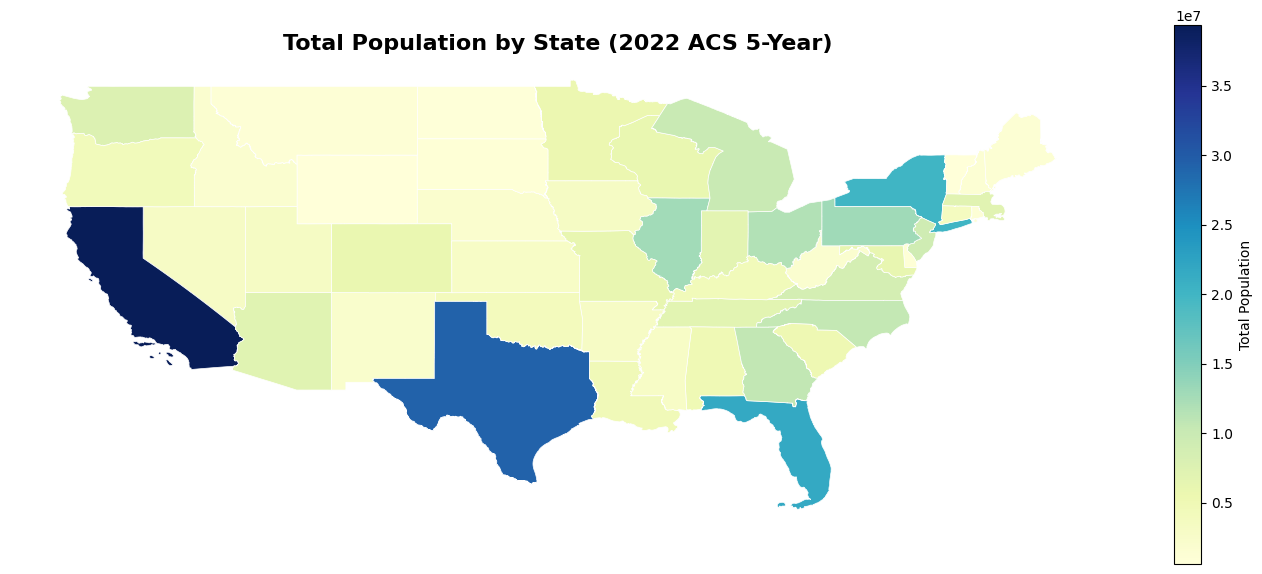

In [7]:
import matplotlib.pyplot as plt

# Filter to continental US for a cleaner map
continental = gdf[~gdf['NAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

# Create a polished choropleth map
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

continental.plot(
    column="B02001_001E",
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
    legend_kwds={"label": "Total Population", "shrink": 0.7}
)

ax.set_title("Total Population by State (2022 ACS 5-Year)", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

> **Note - Supported Geographies**
>
> Geometry fetching currently supports: regions (020), divisions (030), states (040), counties (050), county subdivisions (060), census tracts (140), block groups (150), and places (160).